## Modeling - Machine Learning model creation and evaluation

In [0]:
!pip list | grep xgb

xgboost                            3.1.1
xgboost-ray                        0.1.19


In [0]:
!pip list | grep gbm

lightgbm                           4.6.0


In [0]:
!pip list | grep shap

shap                               0.49.1


In [0]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
from mlflow.models.signature import infer_signature

# Load data from silver table
df = spark.table("crm.customer_info.customer_churn_silver").toPandas()

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
display(df.head())

Dataset shape: (7043, 50)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Binary', 'Tenure_Group', 'Is_Early_Customer', 'Tenure_Years', 'Is_New_Customer', 'Spending_Tier', 'Spend_Rate', 'Is_High_Value', 'Is_Premium_Customer', 'Spending_Stability', 'Num_Internet_Services', 'Has_Phone_Service', 'Has_Internet', 'Total_Services', 'Service_Engagement', 'Has_Streaming', 'Has_Security', 'Is_MonthToMonth', 'Is_Electronic_Check', 'Has_Fiber_Optic', 'Risk_Score', 'Is_High_Risk_Combo', 'Is_Paperless', 'Has_Family', 'gender_Binary', 'Partner_Binary', 'Dependents_Binary', 'PhoneService_Binary', 'PaperlessBilling_Binary']

First few rows:


customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary,Tenure_Group,Is_Early_Customer,Tenure_Years,Is_New_Customer,Spending_Tier,Spend_Rate,Is_High_Value,Is_Premium_Customer,Spending_Stability,Num_Internet_Services,Has_Phone_Service,Has_Internet,Total_Services,Service_Engagement,Has_Streaming,Has_Security,Is_MonthToMonth,Is_Electronic_Check,Has_Fiber_Optic,Risk_Score,Is_High_Risk_Combo,Is_Paperless,Has_Family,gender_Binary,Partner_Binary,Dependents_Binary,PhoneService_Binary,PaperlessBilling_Binary
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,Very_New_0-3m,1,0.08,0,Low,29.85,0,0,0.0,1,0,1,2,Low,0,0,1,1,0,5.46,1,1,1,0,1,0,0,1
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,0,Loyal_25-48m,0,2.83,0,Medium,55.5735294117647,0,0,0.02416980839745917,2,1,1,4,Medium,0,1,0,0,0,-1.415,0,0,0,1,0,0,1,0
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,Very_New_0-3m,1,0.17,0,Medium,54.075,0,0,0.004178272980501419,2,1,1,4,Medium,0,1,1,0,0,3.915,0,1,0,1,0,0,1,1
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No,0,Loyal_25-48m,0,3.75,0,Medium,40.90555555555556,0,0,0.03296558970317822,3,0,1,4,Medium,0,1,0,0,0,-1.875,0,0,0,1,0,0,0,0
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes,1,Very_New_0-3m,1,0.17,0,High,75.825,1,0,0.07248939179632248,0,1,1,2,Low,0,0,1,1,1,6.915,1,1,0,0,0,0,1,1


Target Variable Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Class Proportions:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


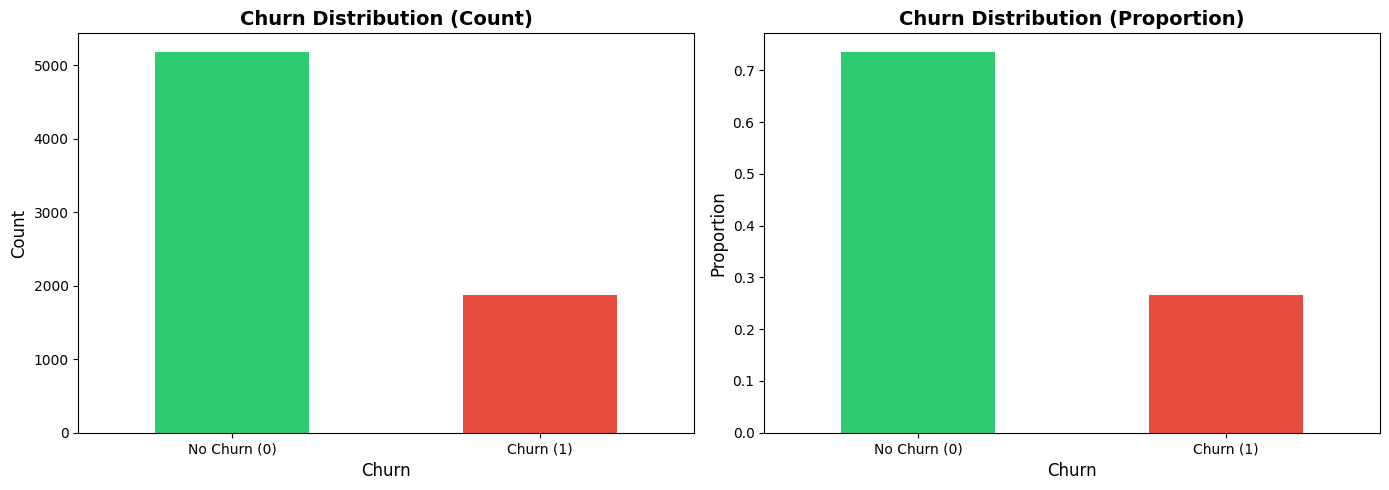


Minority class proportion: 0.2654 (26.54%)


In [0]:
# Check target variable distribution and class balance
print("Target Variable Distribution:")
print(df['Churn'].value_counts())
print(f"\nClass Proportions:")
class_props = df['Churn'].value_counts(normalize=True)
print(class_props)

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)

# Proportion plot
class_props.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Distribution (Proportion)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn', fontsize=12)
axes[1].set_ylabel('Proportion', fontsize=12)
axes[1].set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)

plt.tight_layout()
plt.show()

# Calculate minority class proportion
minority_prop = min(class_props.values)
print(f"\nMinority class proportion: {minority_prop:.4f} ({minority_prop*100:.2f}%)")

Numeric features (6): ['MonthlyCharges', 'TotalCharges', 'Tenure_Years', 'Spend_Rate', 'Spending_Stability', 'Risk_Score']

Categorical features (20): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'Tenure_Group', 'Spending_Tier', 'Service_Engagement']


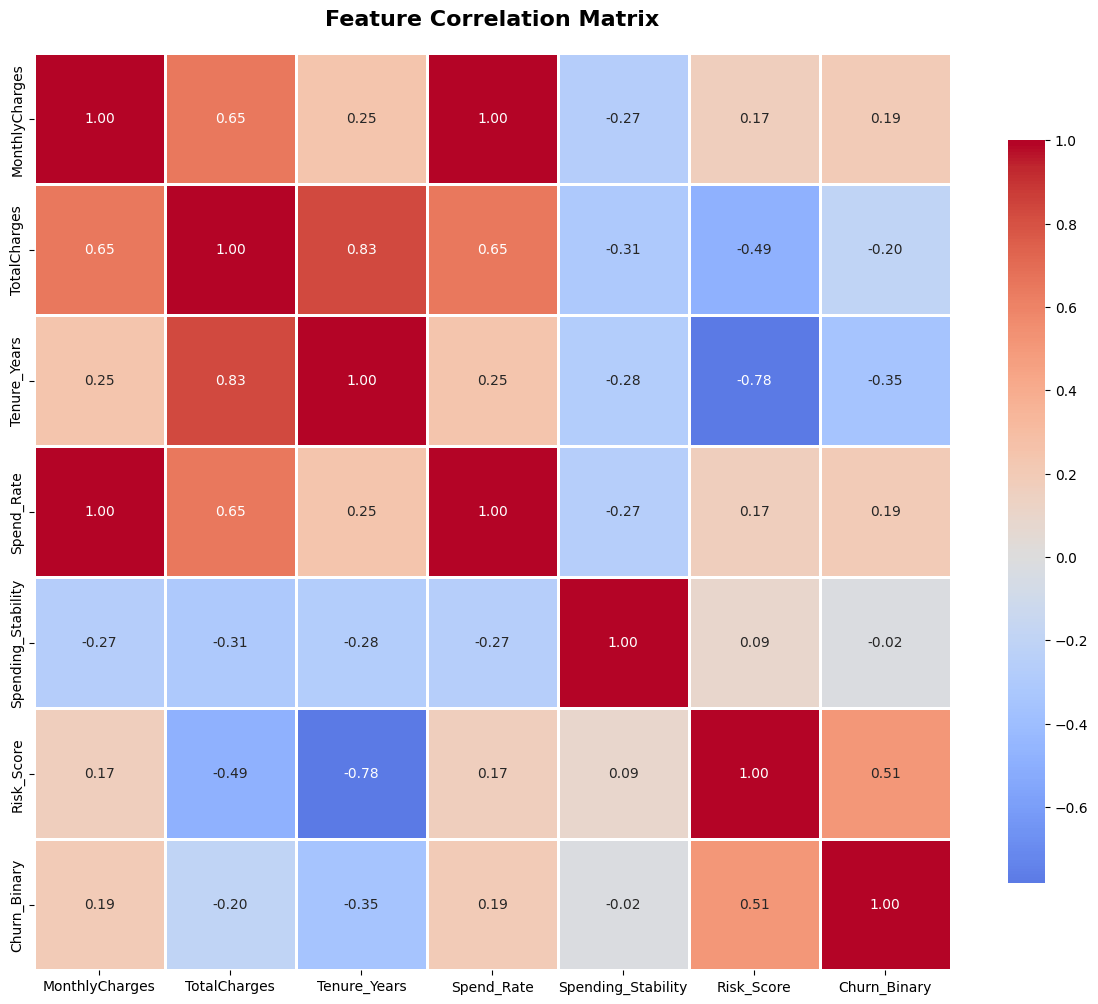


Top features correlated with Churn:
Risk_Score            0.506525
Tenure_Years          0.352291
TotalCharges          0.198347
MonthlyCharges        0.193356
Spend_Rate            0.192531
Spending_Stability    0.018897
Name: Churn_Binary, dtype: float64


In [0]:
# Identify numeric and categorical features
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Churn' in numeric_features:
    numeric_features.remove('Churn')

categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")

# Correlation matrix for numeric features
if len(numeric_features) > 0:
    # Use Churn_Binary (numeric) instead of Churn (string) for correlation
    corr_matrix = df[numeric_features + ['Churn_Binary']].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Show features most correlated with Churn
    churn_corr = corr_matrix['Churn_Binary'].drop('Churn_Binary').abs().sort_values(ascending=False)
    print("\nTop features correlated with Churn:")
    print(churn_corr.head(10))

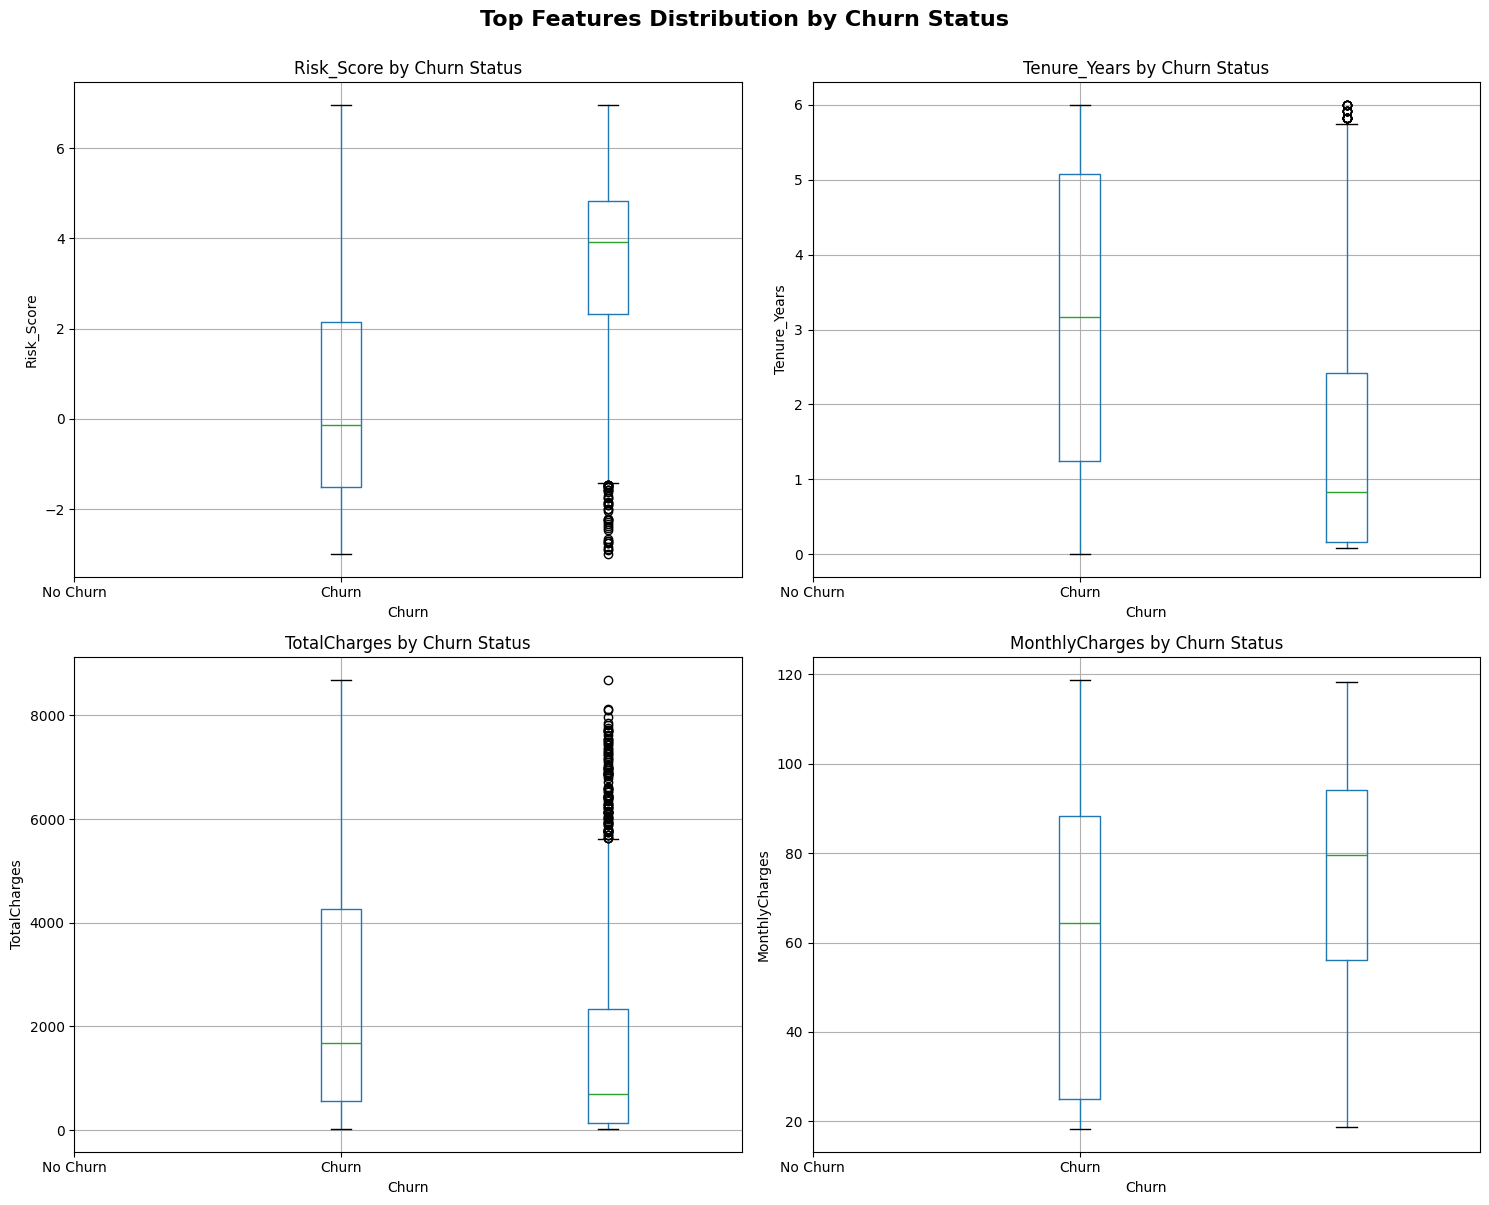

In [0]:
# Visualize top numeric features vs Churn
if len(numeric_features) > 0:
    top_features = df[numeric_features + ['Churn_Binary']].corr()['Churn_Binary'].drop('Churn_Binary').abs().sort_values(ascending=False).head(4).index
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.ravel()
    
    for idx, feature in enumerate(top_features):
        if idx < 4:
            df.boxplot(column=feature, by='Churn_Binary', ax=axes[idx])
            axes[idx].set_title(f'{feature} by Churn Status')
            axes[idx].set_xlabel('Churn')
            axes[idx].set_ylabel(feature)
            plt.sca(axes[idx])
            plt.xticks([0, 1], ['No Churn', 'Churn'])
    
    plt.suptitle('Top Features Distribution by Churn Status', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

In [0]:
# Separate features and target
# Use Churn_Binary (0/1) as target, drop both Churn string columns
X = df.drop(['Churn', 'Churn_Binary'], axis=1)
y = df['Churn_Binary']

# Identify numeric and categorical columns for preprocessing
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nNumeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

# Handle categorical encoding if needed
if len(categorical_cols) > 0:
    print("\nEncoding categorical features...")
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
else:
    X_encoded = X.copy()

print(f"\nFinal feature matrix shape: {X_encoded.shape}")
print(f"Features after encoding: {list(X_encoded.columns)}")

# Check class balance to determine if stratification is needed
minority_class_prop = y.value_counts(normalize=True).min()
print(f"\nMinority class proportion: {minority_class_prop:.4f}")

# Determine if class imbalance exists (threshold: 20% for binary classification)
class_imbalance = minority_class_prop < 0.20

if class_imbalance:
    print(f"⚠️ Class imbalance detected - minority class is {minority_class_prop*100:.2f}% of the data")
    print("Applying stratified split and will use class weighting in models.")
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.2, random_state=42, stratify=y
    )
else:
    print("Class distribution is balanced.")
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.2, random_state=42
    )

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set churn distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest set churn distribution:\n{y_test.value_counts(normalize=True)}")

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data preprocessing completed")

Features shape: (7043, 48)
Target shape: (7043,)

Numeric columns: ['MonthlyCharges', 'TotalCharges', 'Tenure_Years', 'Spend_Rate', 'Spending_Stability', 'Risk_Score']
Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Tenure_Group', 'Spending_Tier', 'Service_Engagement']

Encoding categorical features...

Final feature matrix shape: (7043, 7105)
Features after encoding: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Is_Early_Customer', 'Tenure_Years', 'Is_New_Customer', 'Spend_Rate', 'Is_High_Value', 'Is_Premium_Customer', 'Spending_Stability', 'Num_Internet_Services', 'Has_Phone_Service', 'Has_Internet', 'Total_Services', 'Has_Streaming', 'Has_Security', 'Is_MonthToMonth', 'Is_Electronic_Check', 'Has_Fiber_Optic', 'Risk_Score', 'Is_High_Risk_Combo

In [0]:
# Set up MLflow experiment
mlflow.set_experiment("/Users/<USER_EMAIL>/Customer_churn/churn_prediction_models")

# Dictionary to store models and their results
model_results = {}

# Determine class weight parameter based on class imbalance
if class_imbalance:
    # Calculate scale_pos_weight for XGBoost/LightGBM
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"Class imbalance detected. Using scale_pos_weight: {scale_pos_weight:.2f}\n")
else:
    scale_pos_weight = 1
    print("Classes are balanced. Using default weights.\n")

# Define models
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, 
        max_iter=1000,
        class_weight='balanced' if class_imbalance else None
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1,
        class_weight='balanced' if class_imbalance else None
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, 
        random_state=42,
        learning_rate=0.1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, 
        random_state=42, 
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight if class_imbalance else 1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100, 
        random_state=42,
        class_weight='balanced' if class_imbalance else None,
        verbose=-1
    )
}

print("Training multiple models...\n")
print("="*80)

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    with mlflow.start_run(run_name=model_name):
        # Log parameters
        mlflow.log_params(model.get_params())
        
        # Train model
        if model_name in ['Logistic Regression']:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        elif model_name == 'Gradient Boosting':
            # Apply sample weights for Gradient Boosting if imbalanced
            if class_imbalance:
                sample_weights = np.where(y_train == 1, scale_pos_weight, 1.0)
                model.fit(X_train, y_train, sample_weight=sample_weights)
            else:
                model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        # Log metrics
        mlflow.log_metrics({
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc
        })
        
        # Store results
        model_results[model_name] = {
            'model': model,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        }
        
        # Log model
        if model_name == 'XGBoost':
            signature = infer_signature(X_train, model.predict(X_train))
            mlflow.xgboost.log_model(model, "model", signature=signature)
        elif model_name == 'LightGBM':
            signature = infer_signature(X_train, model.predict(X_train))
            mlflow.lightgbm.log_model(model, "model", signature=signature)
        else:
            signature = infer_signature(X_train if model_name != 'Logistic Regression' else X_train_scaled, 
                                       model.predict(X_train if model_name != 'Logistic Regression' else X_train_scaled))
            mlflow.sklearn.log_model(model, "model", signature=signature)
        
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        print(f"  ROC-AUC: {roc_auc:.4f}")

print("\n" + "="*80)
print("✓ All models trained successfully")

2026/07/07 02:49:11 INFO mlflow.tracking.fluent: Experiment with name '/Users/<USER_EMAIL>/Customer_churn/churn_prediction_models' does not exist. Creating a new experiment.


Classes are balanced. Using default weights.

Training multiple models...


Training Logistic Regression...


2026/07/07 02:49:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://<DATABRICKS_HOST>/ml/experiments/<EXPERIMENT_ID>/models/m-bb4facffd2814e86a86ea7b81cebc7d8?o=<WORKSPACE_ID>


  Accuracy: 0.8062
  Precision: 0.7033
  Recall: 0.4638
  F1-Score: 0.5590
  ROC-AUC: 0.8642

Training Random Forest...


/opt/databricks-environments/databricks-ml/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/07 02:49:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://<DATABRICKS_HOST>/ml/experiments/<EXPERIMENT_ID>/models/m-e34ed3e0936d4197953

...

  Accuracy: 0.8176
  Precision: 0.6883
  Recall: 0.5684
  F1-Score: 0.6226
  ROC-AUC: 0.8636

Training XGBoost...


/opt/databricks-environments/databricks-ml/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/07 02:50:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://<DATABRICKS_HOST>/ml/experiments/<EXPERIMENT_ID>/models/m-63f5728e03984a66ad9

  Accuracy: 0.7942
  Precision: 0.6370
  Recall: 0.5174
  F1-Score: 0.5710
  ROC-AUC: 0.8438

Training LightGBM...


/opt/databricks-environments/databricks-ml/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/07 02:51:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://<DATABRICKS_HOST>/ml/experiments/<EXPERIMENT_ID>/models/m-04f5701e68474428bfd

  Accuracy: 0.8119
  Precision: 0.6765
  Recall: 0.5550
  F1-Score: 0.6097
  ROC-AUC: 0.8557

✓ All models trained successfully


Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.806246,0.703252,0.463807,0.558966,0.864167
2,Gradient Boosting,0.817601,0.688312,0.568365,0.622614,0.863619
4,LightGBM,0.811923,0.676471,0.554960,0.609720,0.855708
1,Random Forest,0.799858,0.667897,0.485255,0.562112,0.849078
3,XGBoost,0.794180,0.636964,0.517426,0.571006,0.843827


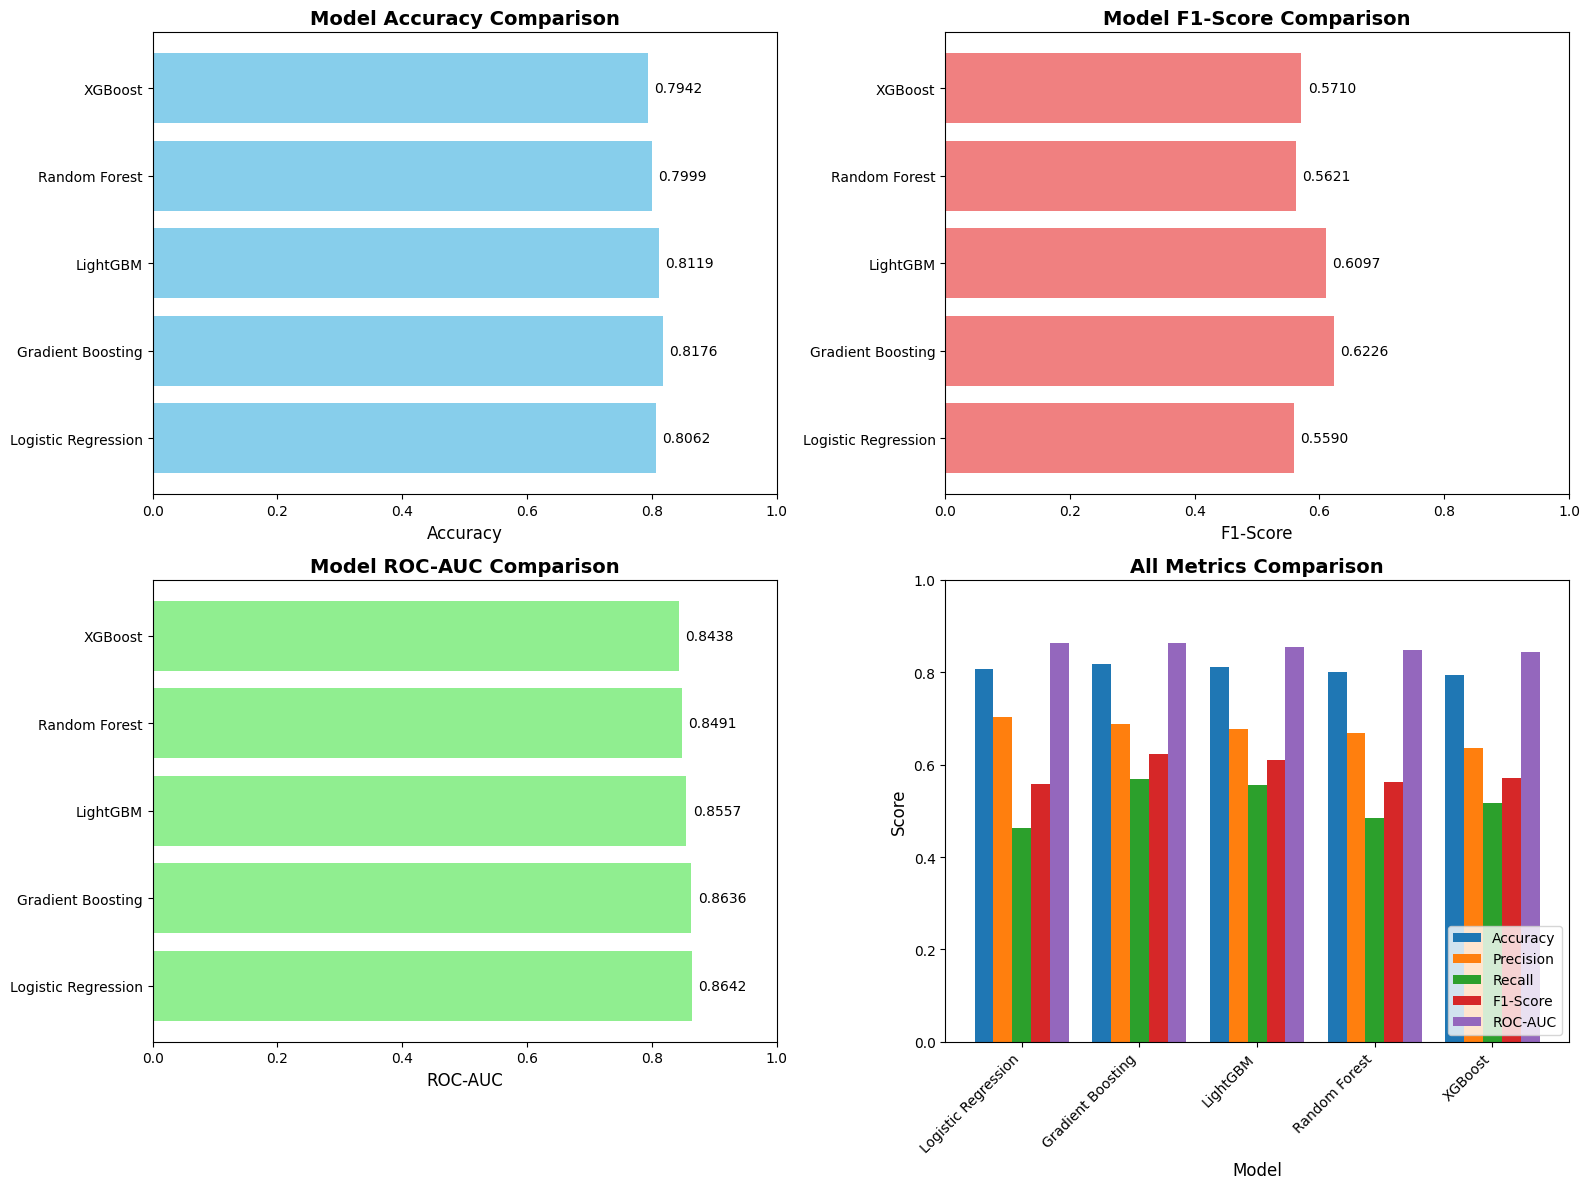


🏆 Best performing model: Logistic Regression (ROC-AUC: 0.8642)


In [0]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Accuracy': [results['accuracy'] for results in model_results.values()],
    'Precision': [results['precision'] for results in model_results.values()],
    'Recall': [results['recall'] for results in model_results.values()],
    'F1-Score': [results['f1_score'] for results in model_results.values()],
    'ROC-AUC': [results['roc_auc'] for results in model_results.values()]
})

comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)
print("Model Performance Comparison:")
print("="*80)
display(comparison_df.style.background_gradient(cmap='RdYlGn', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']))

# Visualize performance metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy comparison
axes[0, 0].barh(comparison_df['Model'], comparison_df['Accuracy'], color='skyblue')
axes[0, 0].set_xlabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlim([0, 1])
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0, 0].text(v + 0.01, i, f'{v:.4f}', va='center')

# F1-Score comparison
axes[0, 1].barh(comparison_df['Model'], comparison_df['F1-Score'], color='lightcoral')
axes[0, 1].set_xlabel('F1-Score', fontsize=12)
axes[0, 1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlim([0, 1])
for i, v in enumerate(comparison_df['F1-Score']):
    axes[0, 1].text(v + 0.01, i, f'{v:.4f}', va='center')

# ROC-AUC comparison
axes[1, 0].barh(comparison_df['Model'], comparison_df['ROC-AUC'], color='lightgreen')
axes[1, 0].set_xlabel('ROC-AUC', fontsize=12)
axes[1, 0].set_title('Model ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xlim([0, 1])
for i, v in enumerate(comparison_df['ROC-AUC']):
    axes[1, 0].text(v + 0.01, i, f'{v:.4f}', va='center')

# All metrics together
metrics = comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
metrics.plot(kind='bar', ax=axes[1, 1], width=0.8)
axes[1, 1].set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Model', fontsize=12)
axes[1, 1].set_ylabel('Score', fontsize=12)
axes[1, 1].set_ylim([0, 1])
axes[1, 1].legend(loc='lower right')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best performing model: {best_model_name} (ROC-AUC: {comparison_df.iloc[0]['ROC-AUC']:.4f})")

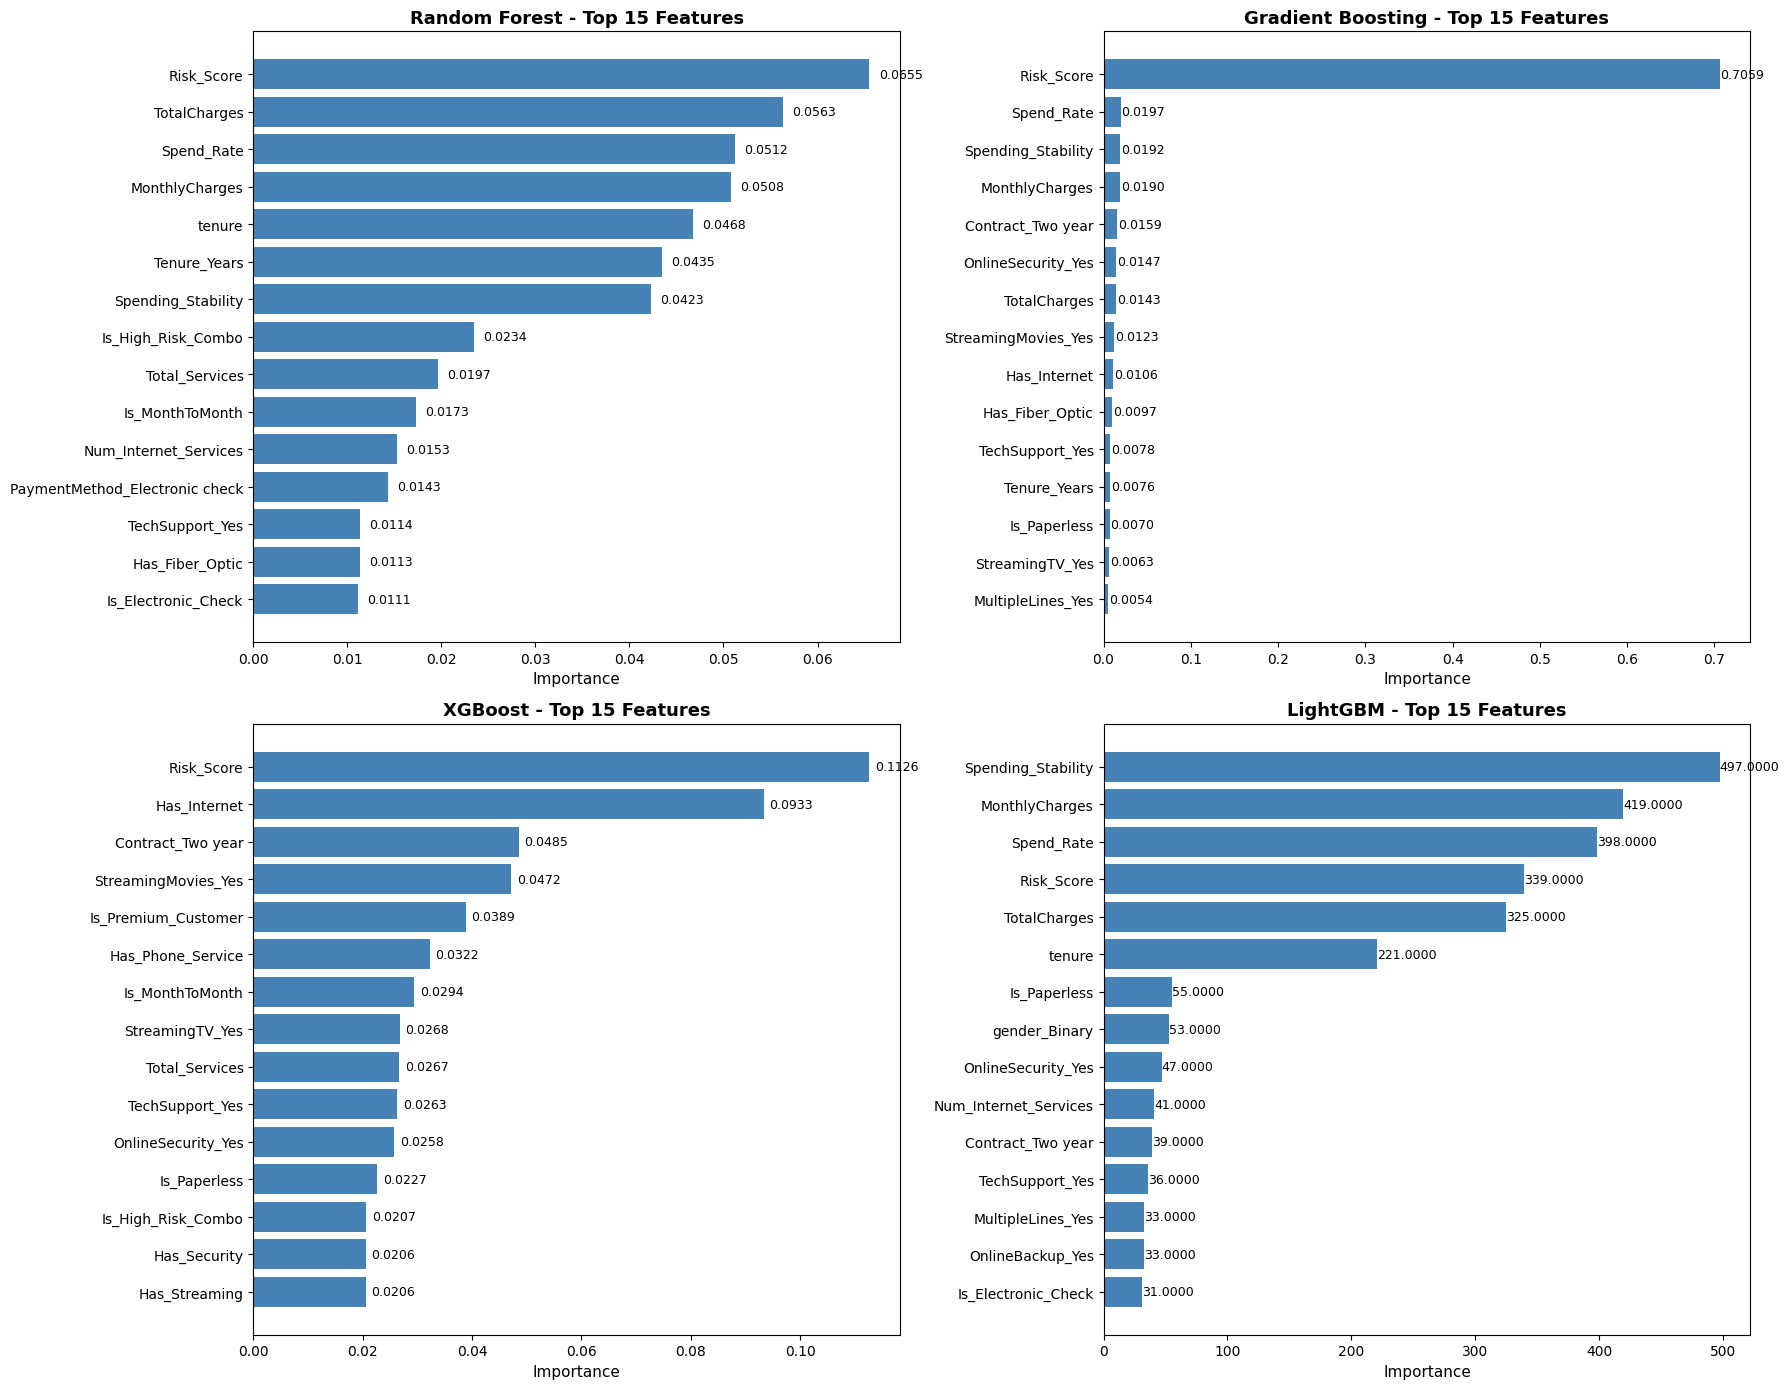


Top 10 Most Important Features from Logistic Regression:


In [0]:
# Feature importance for tree-based models
tree_models = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.ravel()

for idx, model_name in enumerate(tree_models):
    if model_name in model_results:
        model = model_results[model_name]['model']
        
        # Get feature importances
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            feature_names = X_train.columns
            
            # Create DataFrame and sort
            importance_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': importances
            }).sort_values('Importance', ascending=False).head(15)
            
            # Plot
            axes[idx].barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
            axes[idx].set_xlabel('Importance', fontsize=11)
            axes[idx].set_title(f'{model_name} - Top 15 Features', fontsize=13, fontweight='bold')
            axes[idx].invert_yaxis()
            
            for i, v in enumerate(importance_df['Importance']):
                axes[idx].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print top features from best model
print(f"\nTop 10 Most Important Features from {best_model_name}:")
print("="*60)
best_model = model_results[best_model_name]['model']
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)
    display(importance_df)

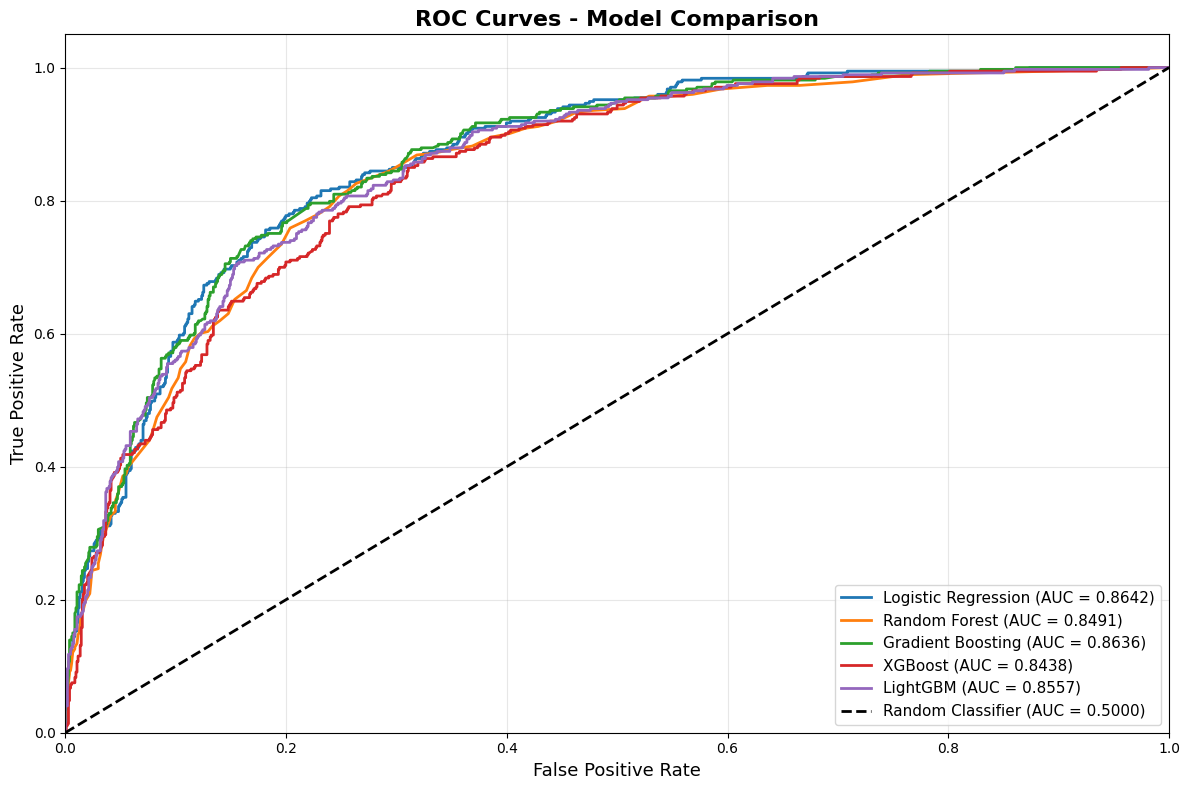

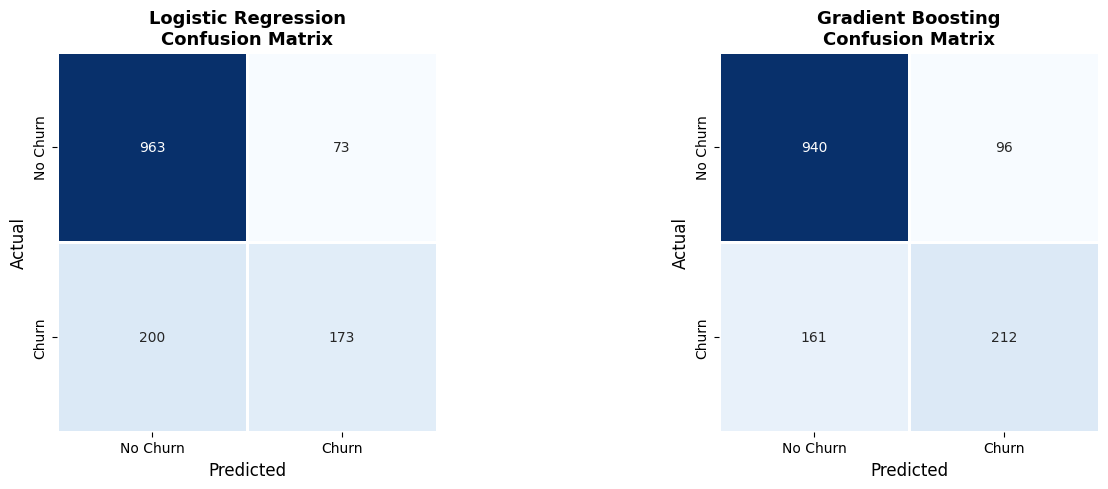

In [0]:
# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

for model_name, results in model_results.items():
    y_pred_proba = results['y_pred_proba']
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = results['roc_auc']
    
    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves - Model Comparison', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrices for top 2 models
top_2_models = comparison_df.head(2)['Model'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, model_name in enumerate(top_2_models):
    y_pred = model_results[model_name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                cbar=False, square=True, linewidths=2)
    axes[idx].set_xlabel('Predicted', fontsize=12)
    axes[idx].set_ylabel('Actual', fontsize=12)
    axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    axes[idx].set_xticklabels(['No Churn', 'Churn'])
    axes[idx].set_yticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

In [0]:
# Perform hyperparameter tuning on the best model
print(f"Performing hyperparameter tuning on {best_model_name}...\n")

# Define parameter grids based on best model
if best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    }
    base_model = XGBClassifier(
        random_state=42, 
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight if class_imbalance else 1
    )
elif best_model_name == 'LightGBM':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, -1],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [20, 31, 40],
        'subsample': [0.8, 0.9, 1.0]
    }
    base_model = LGBMClassifier(
        random_state=42,
        class_weight='balanced' if class_imbalance else None,
        verbose=-1
    )
elif best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight='balanced' if class_imbalance else None
    )
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 0.9, 1.0]
    }
    base_model = GradientBoostingClassifier(random_state=42)
else:  # Logistic Regression
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    }
    base_model = LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced' if class_imbalance else None
    )

print(f"Parameter grid: {param_grid}\n")

# Use RandomizedSearchCV for efficiency
random_search = RandomizedSearchCV(
    base_model,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit the model
if best_model_name == 'Logistic Regression':
    random_search.fit(X_train_scaled, y_train)
    X_test_for_pred = X_test_scaled
else:
    if best_model_name == 'Gradient Boosting' and class_imbalance:
        sample_weights = np.where(y_train == 1, scale_pos_weight, 1.0)
        random_search.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        random_search.fit(X_train, y_train)
    X_test_for_pred = X_test

print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best cross-validation ROC-AUC: {random_search.best_score_:.4f}\n")

# Evaluate tuned model on test set
tuned_model = random_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_for_pred)
y_pred_proba_tuned = tuned_model.predict_proba(X_test_for_pred)[:, 1]

# Calculate metrics for tuned model
tuned_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_tuned),
    'precision': precision_score(y_test, y_pred_tuned),
    'recall': recall_score(y_test, y_pred_tuned),
    'f1_score': f1_score(y_test, y_pred_tuned),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_tuned)
}

print("Tuned Model Performance:")
print("="*60)
for metric, value in tuned_metrics.items():
    print(f"{metric.replace('_', ' ').title()}: {value:.4f}")

Performing hyperparameter tuning on Logistic Regression...

Parameter grid: {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/opt/databricks-environments/databricks-ml/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 1}
Best cross-validation ROC-AUC: 0.8400

Tuned Model Performance:
Accuracy: 0.8084
Precision: 0.6782
Recall: 0.5255
F1 Score: 0.5921
Roc Auc: 0.8637



Logistic Regression - Performance Comparison


,Metric,Before Tuning,After Tuning,Improvement,Improvement %
0,Accuracy,0.806246,0.808375,0.002129,0.264085
1,Precision,0.703252,0.678201,-0.025051,-3.562214
2,Recall,0.463807,0.525469,0.061662,13.294798
3,F1 Score,0.558966,0.592145,0.033179,5.935770
4,Roc Auc,0.864167,0.863684,-0.000484,-0.055998


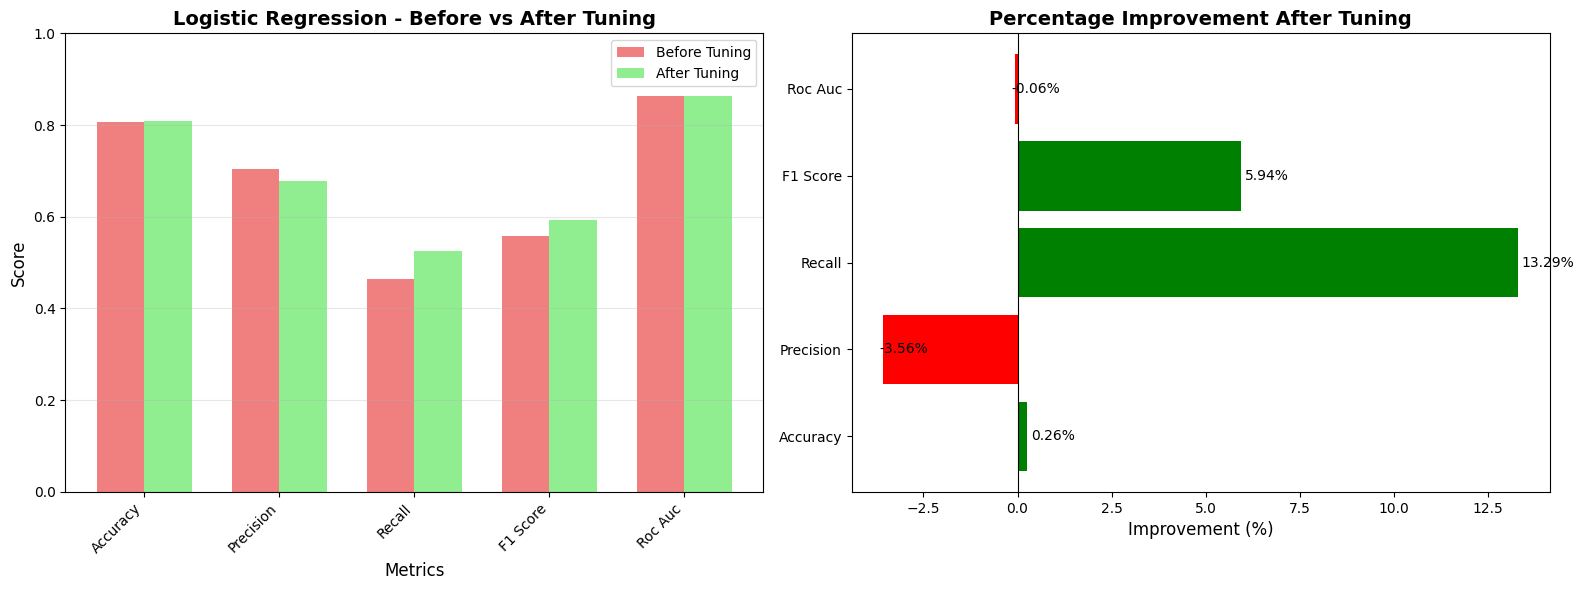


✓ Hyperparameter tuning completed!
Average improvement: 3.18%


In [0]:
# Compare before and after tuning
original_metrics = {
    'accuracy': model_results[best_model_name]['accuracy'],
    'precision': model_results[best_model_name]['precision'],
    'recall': model_results[best_model_name]['recall'],
    'f1_score': model_results[best_model_name]['f1_score'],
    'roc_auc': model_results[best_model_name]['roc_auc']
}

improvement_df = pd.DataFrame({
    'Metric': [m.replace('_', ' ').title() for m in tuned_metrics.keys()],
    'Before Tuning': [original_metrics[m] for m in tuned_metrics.keys()],
    'After Tuning': list(tuned_metrics.values()),
    'Improvement': [tuned_metrics[m] - original_metrics[m] for m in tuned_metrics.keys()],
    'Improvement %': [(tuned_metrics[m] - original_metrics[m]) / original_metrics[m] * 100 for m in tuned_metrics.keys()]
})

print(f"\n{best_model_name} - Performance Comparison")
print("="*80)
display(improvement_df.style.background_gradient(cmap='RdYlGn', subset=['Improvement']))

# Visualize improvement
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Side-by-side comparison
x = np.arange(len(improvement_df))
width = 0.35

axes[0].bar(x - width/2, improvement_df['Before Tuning'], width, label='Before Tuning', color='lightcoral')
axes[0].bar(x + width/2, improvement_df['After Tuning'], width, label='After Tuning', color='lightgreen')
axes[0].set_xlabel('Metrics', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title(f'{best_model_name} - Before vs After Tuning', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace('_', ' ').title() for m in improvement_df['Metric']], rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')

# Improvement percentage
colors = ['green' if x > 0 else 'red' for x in improvement_df['Improvement %']]
axes[1].barh(improvement_df['Metric'], improvement_df['Improvement %'], color=colors)
axes[1].set_xlabel('Improvement (%)', fontsize=12)
axes[1].set_title('Percentage Improvement After Tuning', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
for i, v in enumerate(improvement_df['Improvement %']):
    axes[1].text(v + 0.1 if v > 0 else v - 0.1, i, f'{v:.2f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n✓ Hyperparameter tuning completed!")
print(f"Average improvement: {improvement_df['Improvement %'].mean():.2f}%")

Generating SHAP explanations...

✓ SHAP values computed

Feature Impact Summary (SHAP):


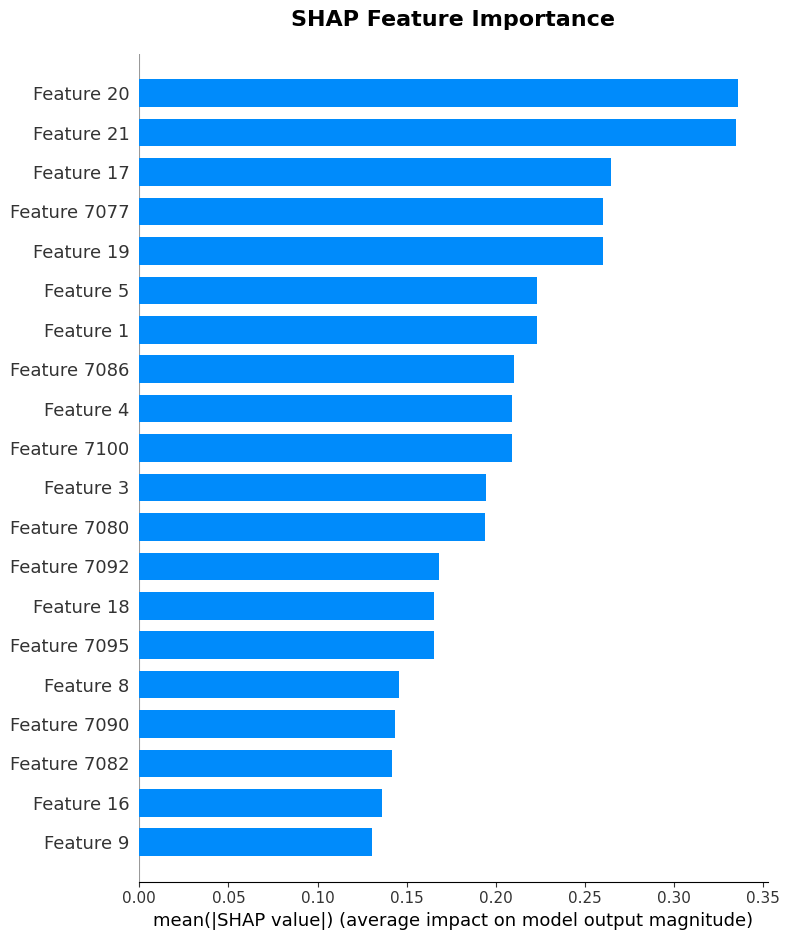


Detailed SHAP Summary Plot (Impact Direction):


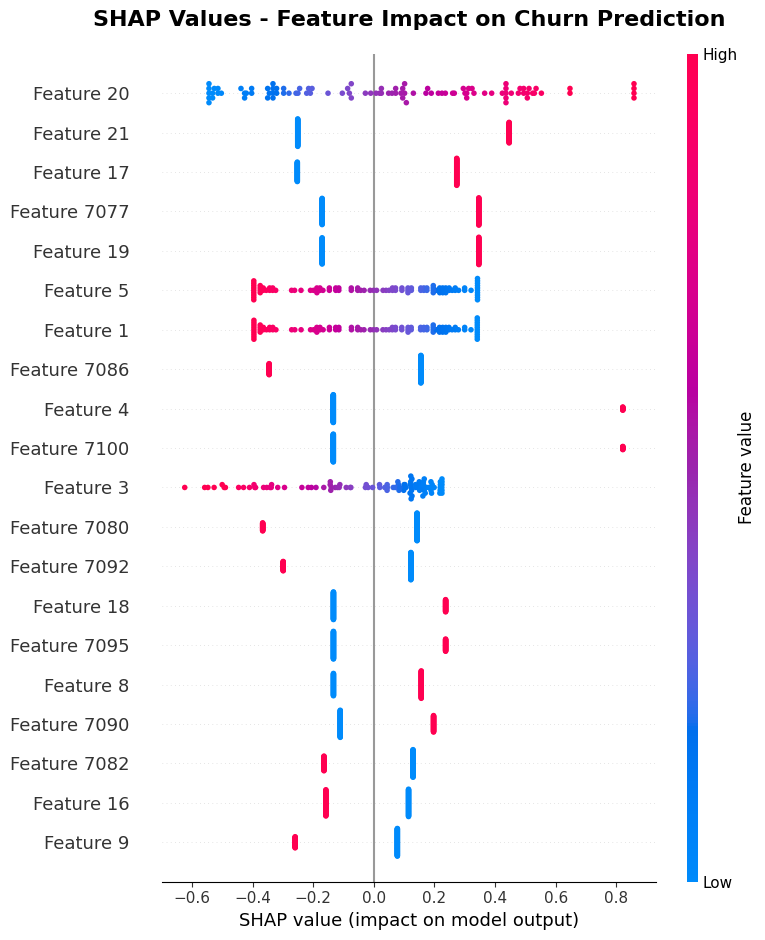


🔍 Key Insights from SHAP Analysis:
- Red dots = Higher feature values
- Blue dots = Lower feature values
- Horizontal position = Impact on prediction (positive pushes toward churn)
- Features at top have the most significant impact on predictions


In [0]:
# SHAP values for model interpretation
import shap

print("Generating SHAP explanations...\n")

# Use a sample of data for SHAP (for efficiency)
sample_size = min(100, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42) if best_model_name != 'Logistic Regression' else X_test_scaled[:sample_size]

# Create SHAP explainer based on model type
if best_model_name in ['XGBoost', 'LightGBM']:
    explainer = shap.TreeExplainer(tuned_model)
    shap_values = explainer.shap_values(X_sample)
elif best_model_name in ['Random Forest', 'Gradient Boosting']:
    explainer = shap.TreeExplainer(tuned_model)
    shap_values = explainer.shap_values(X_sample)
    # For binary classification, use positive class
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:  # Logistic Regression
    explainer = shap.LinearExplainer(tuned_model, X_train_scaled)
    shap_values = explainer.shap_values(X_sample)

print("✓ SHAP values computed\n")

# Summary plot - shows feature importance and impact
print("Feature Impact Summary (SHAP):")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title('SHAP Feature Importance', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Detailed SHAP summary plot
print("\nDetailed SHAP Summary Plot (Impact Direction):")
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Values - Feature Impact on Churn Prediction', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n🔍 Key Insights from SHAP Analysis:")
print("- Red dots = Higher feature values")
print("- Blue dots = Lower feature values")
print("- Horizontal position = Impact on prediction (positive pushes toward churn)")
print("- Features at top have the most significant impact on predictions")

Example: SHAP Explanation for a Single Customer Prediction

Sample index: 0
Actual churn status: 1
Predicted churn probability: 0.8954



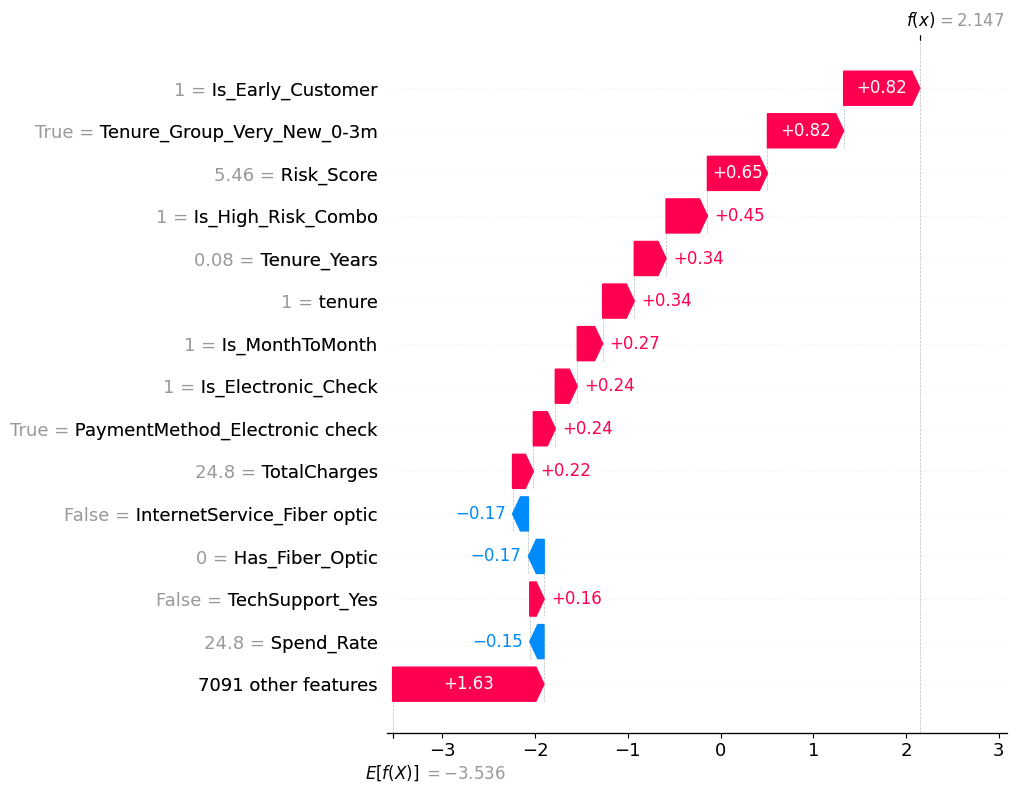


The waterfall plot shows how each feature contributes to moving the prediction from the base value (expected value) to the final prediction.


In [0]:
# Show SHAP waterfall plot for a specific prediction
print("Example: SHAP Explanation for a Single Customer Prediction\n")

# Select a sample index - handle both DataFrame and numpy array
if isinstance(X_sample, pd.DataFrame):
    sample_idx = 0
    print(f"Customer index: {X_sample.index[sample_idx]}")
    print(f"Actual churn status: {y_test.loc[X_sample.index[sample_idx]]}")
    print(f"Predicted churn probability: {tuned_model.predict_proba(X_sample.iloc[[sample_idx]])[0][1]:.4f}\n")
    sample_data = X_sample.iloc[sample_idx]
    feature_names = X_sample.columns.tolist()
else:
    # X_sample is numpy array (for Logistic Regression)
    sample_idx = 0
    print(f"Sample index: {sample_idx}")
    print(f"Actual churn status: {y_test.iloc[sample_idx]}")
    print(f"Predicted churn probability: {tuned_model.predict_proba(X_sample[[sample_idx]])[0][1]:.4f}\n")
    sample_data = X_test.iloc[sample_idx]
    feature_names = X_train.columns.tolist()

# Create explanation object for waterfall plot
if best_model_name in ['XGBoost', 'LightGBM', 'Random Forest', 'Gradient Boosting']:
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
        data=sample_data,
        feature_names=feature_names
    ), show=True, max_display=15)
else:
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=sample_data,
        feature_names=feature_names
    ), show=True, max_display=15)

print("\nThe waterfall plot shows how each feature contributes to moving the prediction from the base value (expected value) to the final prediction.")

## Business Recommendations and Next Steps

In [0]:
print("="*80)
print("BUSINESS INSIGHTS AND RECOMMENDATIONS")
print("="*80)

print("\n📊 MODEL PERFORMANCE SUMMARY")
print("-" * 80)
print(f"Best Model: {best_model_name}")
print(f"Final ROC-AUC Score: {tuned_metrics['roc_auc']:.4f}")
print(f"Final F1-Score: {tuned_metrics['f1_score']:.4f}")
print(f"Accuracy: {tuned_metrics['accuracy']:.4f}")
print(f"Precision: {tuned_metrics['precision']:.4f} (of predicted churners, this % actually churned)")
print(f"Recall: {tuned_metrics['recall']:.4f} (of actual churners, we correctly identified this %)")

# Get top features
if hasattr(tuned_model, 'feature_importances_'):
    top_features_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': tuned_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(5)
    
    print("\n🎯 KEY CHURN DRIVERS (Top 5)")
    print("-" * 80)
    for idx, row in top_features_df.iterrows():
        print(f"{row['Feature']}: {row['Importance']:.4f}")

print("\n💡 ACTIONABLE BUSINESS RECOMMENDATIONS")
print("-" * 80)
print("""
1. TARGETED RETENTION CAMPAIGNS
   - Focus on customers with high churn probability scores (>0.7)
   - Implement early warning system using top predictive features
   - Design personalized retention offers based on customer segments

2. CUSTOMER SEGMENTATION STRATEGY
   - Segment customers by churn risk: High (>0.7), Medium (0.4-0.7), Low (<0.4)
   - Allocate retention budget proportionally to risk segments
   - Monitor segment migration patterns monthly

3. FEATURE-DRIVEN INTERVENTIONS
   - Address the top churn drivers identified in feature importance
   - Create action plans for each critical feature
   - Set up automated alerts when customers enter high-risk thresholds

4. CONTINUOUS MONITORING
   - Deploy model to score customers weekly/monthly
   - Track model performance drift using ROC-AUC and calibration metrics
   - Retrain model quarterly with new data to maintain accuracy

5. A/B TESTING FRAMEWORK
   - Test retention strategies on high-risk customers
   - Measure impact: retention rate, customer lifetime value, ROI
   - Iterate based on results to optimize interventions
""")

print("\n🚀 NEXT STEPS FOR MODEL DEPLOYMENT")
print("-" * 80)
print("""
1. MODEL DEPLOYMENT
   - Register best model to Unity Catalog
   - Deploy as REST API endpoint for real-time scoring
   - Integrate with CRM system for automated risk flagging

2. MONITORING INFRASTRUCTURE
   - Set up model performance dashboards
   - Configure data drift detection alerts
   - Schedule automatic retraining pipeline

3. STAKEHOLDER ENABLEMENT
   - Create user-friendly dashboard showing churn predictions
   - Provide feature explanation reports to business teams
   - Train customer success team on model outputs

4. CONTINUOUS IMPROVEMENT
   - Collect feedback on model predictions from business users
   - Incorporate new features as they become available
   - Experiment with advanced techniques (ensemble, deep learning)
   - Measure business impact: saved customers, revenue retention
""")

print("\n✓ Analysis Complete!")
print("="*80)

BUSINESS INSIGHTS AND RECOMMENDATIONS

📊 MODEL PERFORMANCE SUMMARY
--------------------------------------------------------------------------------
Best Model: Logistic Regression
Final ROC-AUC Score: 0.8637
Final F1-Score: 0.5921
Accuracy: 0.8084
Precision: 0.6782 (of predicted churners, this % actually churned)
Recall: 0.5255 (of actual churners, we correctly identified this %)

💡 ACTIONABLE BUSINESS RECOMMENDATIONS
--------------------------------------------------------------------------------

1. TARGETED RETENTION CAMPAIGNS
   - Focus on customers with high churn probability scores (>0.7)
   - Implement early warning system using top predictive features
   - Design personalized retention offers based on customer segments

2. CUSTOMER SEGMENTATION STRATEGY
   - Segment customers by churn risk: High (>0.7), Medium (0.4-0.7), Low (<0.4)
   - Allocate retention budget proportionally to risk segments
   - Monitor segment migration patterns monthly

3. FEATURE-DRIVEN INTERVENTIONS
   -